In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import torch

import shimnet

In [ ]:
from enum import Enum

class PeaksParametersNames(Enum):
    tff_lin = "position_hz"
    thf_lin = "height"
    twf_lin = "width_hz"
    trf_lin = "gaussian_fraction"

    @classmethod
    def keys(cls):
        return [member.value for member in cls]
    
    @classmethod
    def values(cls):
        return [member.name for member in cls]

class SpectrumPeaksParser:
    def __init__(self,
        alias_position_hz = None,
        alias_height = None,
        alias_width_hz = None,
        alias_gaussian_fraction = None,
        default_position_hz = None,
        default_height = None,
        default_width_hz = None,
        default_gaussian_fraction = 0.,
        ):
        self.alias_position_hz = alias_position_hz if alias_position_hz is not None else "position_hz"
        self.alias_height = alias_height if alias_height is not None else "height"
        self.alias_width_hz = alias_width_hz if alias_width_hz is not None else "width_hz"
        self.alias_gaussian_fraction = alias_gaussian_fraction if alias_gaussian_fraction is not None else "gaussian_fraction"
        self.default_position_hz = default_position_hz
        self.default_height = default_height
        self.default_width_hz = default_width_hz
        self.default_gaussian_fraction = default_gaussian_fraction

    def parse(self, spectrum_peaks):
        parsed_peaks = []
        for peak in spectrum_peaks:
            parsed_peak = {
                PeaksParametersNames("position_hz").name: peak.get(self.alias_position_hz, self.default_position_hz),
                PeaksParametersNames("height").name: peak.get(self.alias_height, self.default_height),
                PeaksParametersNames("width_hz").name: peak.get(self.alias_width_hz, self.default_width_hz),
                PeaksParametersNames("gaussian_fraction").name: peak.get(self.alias_gaussian_fraction, self.default_gaussian_fraction),
            }
            # Validate and convert other peak parameters
            for k, v in parsed_peak.items():
                if v is None:
                    raise ValueError(f"Peak parameter '{k}' is None.")
                parsed_peak[k] = torch.atleast_1d(torch.tensor(v, dtype=torch.float32))
            parsed_peaks.append(parsed_peak)
        return parsed_peaks


In [59]:
substance_peaks_data

[{'tff_lin': tensor([25.6000]),
  'thf_lin': tensor([30.4000]),
  'twf_lin': tensor([5.]),
  'trf_lin': tensor([0.])},
 {'tff_lin': tensor([152.3000]),
  'thf_lin': tensor([12.1000]),
  'twf_lin': tensor([22.]),
  'trf_lin': tensor([0.])}]

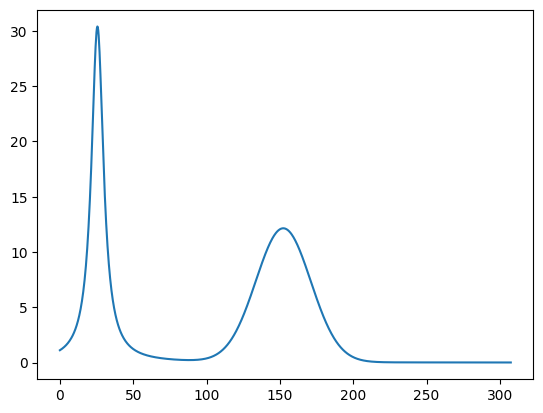

In [66]:
spectrum_peaks = [
    {
        "name": "Peak 1",
        "height": 30.4,
        "position_hz": 25.6,
        "width_hz": 5.0,
    },
    {
        "name": "Peak 2",
        "height": 12.1,
        "position_hz": 152.3,
        "width_hz": 22.0,
        "gaussian_fraction": 1.0,
    }
]
pd.DataFrame(spectrum_peaks).to_csv("data/substance1.csv", index=False)

parser = SpectrumPeaksParser()
frequencies = torch.arange(1024) * 0.30048  # Example frequency axis from 0 to 600 Hz with 1 Hz step

substance_peaks_data = parser.parse(spectrum_peaks)
substance_spectrum = shimnet.generators.spectrum_from_peaks_data(substance_peaks_data, frequencies)
plt.plot(frequencies.numpy(), substance_spectrum[0].numpy())